In [4]:
import os 
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve
import re
import math
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score
import joblib
import time
from ultralytics import YOLO

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 入力画像パスとモデル
# img_path = "/home/data/jikuari_maesyori/cropBB/C/IMG_1718.JPEG"
img_path = "/home/data/0203_energee_after/cropBB/B/IMG_1703.JPEG"
segmentation_model = YOLO("/home/YOLO/-327_seg/datasets/train2/weights/best.pt")

# 画像を読み込み（OpenCV形式）
clip_img = cv2.imread(img_path)

# セグメンテーション予測
mask_results = segmentation_model.predict(clip_img)

# マスクが存在する場合
if mask_results and mask_results[0].masks is not None:
    # マスクを NumPy 配列に変換し、0-255 の範囲にする
    mask = mask_results[0].masks.data[0].cpu().numpy()
    mask = (mask * 255).astype(np.uint8)

    # マスク画像を元画像サイズにリサイズ
    mask_resized = cv2.resize(mask, (clip_img.shape[1], clip_img.shape[0]))

    output_path = "/home/test_hozon/mask_1703.jpg"
    cv2.imwrite(output_path, mask_resized)
    print(f"マスク画像を保存しました: {output_path}")
#     # 表示
#     plt.figure(figsize=(6, 6))
#     plt.imshow(mask_resized, cmap='gray')
#     plt.axis('off')
#     # plt.title("Segmentation Mask")
#     plt.show()
# else:
#     print("マスクが検出されませんでした。")



0: 640x608 1 shiitake, 32.7ms
Speed: 0.8ms preprocess, 32.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 608)
マスク画像を保存しました: /home/test_hozon/mask_1703.jpg


最小直径: 427.38 ピクセル
最大直径: 520.33 ピクセル
最小: (20.56, 320.92) ⇄ (430.06, 203.49)
最大: (346.98, 493.69) ⇄ (117.71, 23.62)
(511, 466, 3)


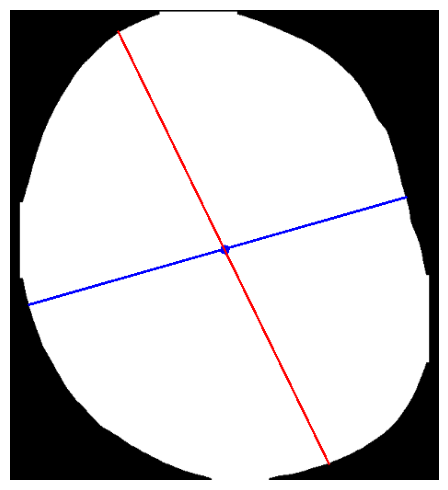

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === マスク画像の読み込み（グレースケール） ===
# mask = cv2.imread("/home/data/0203_energee_after/maskBB/B/IMG_1703.JPEG", cv2.IMREAD_GRAYSCALE)
mask = mask_resized

# 0以外を白（255）に変換してバイナリマスク作成
# しきい値処理（2値化）
_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# 輪郭検出
contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 最大輪郭のみ使用
if contours:
    largest_contour = max(contours, key=cv2.contourArea)

    # モーメントから重心計算
    M = cv2.moments(largest_contour)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        center_of_mass = np.array([cx, cy])
    else:
        print("面積ゼロの輪郭")
        center_of_mass = np.array([0, 0])
else:
    print("輪郭が見つかりませんでした")
    center_of_mass = np.array([0, 0])

# === 最小・最大距離初期化 ===
min_distance = float('inf')
max_distance = 0
min_points = None
max_points = None

# 角度を変えながら探索（0〜179度）
for angle in range(0, 180):
    angle_rad = np.deg2rad(angle)
    dx = np.cos(angle_rad)
    dy = np.sin(angle_rad)

    # 正方向に進む
    x, y = center_of_mass
    farthest_x, farthest_y = None, None
    while 0 <= int(x) < mask.shape[1] and 0 <= int(y) < mask.shape[0]:
        if mask_bin[int(y), int(x)] == 0:
            farthest_x, farthest_y = x, y
            break
        x += dx
        y += dy

    # 負方向に進む
    x, y = center_of_mass
    nearest_x, nearest_y = None, None
    while 0 <= int(x) < mask.shape[1] and 0 <= int(y) < mask.shape[0]:
        if mask_bin[int(y), int(x)] == 0:
            nearest_x, nearest_y = x, y
            break
        x -= dx
        y -= dy

    # 有効な点が見つかった場合のみ距離を計算
    if farthest_x is not None and nearest_x is not None:
        dist = np.sqrt(((farthest_x - nearest_x)-2)**2 + ((farthest_y - nearest_y)-2)**2)

        if dist < min_distance:
            min_distance = dist
            min_points = ((farthest_x, farthest_y), (nearest_x, nearest_y))

        if dist > max_distance:
            max_distance = dist
            max_points = ((farthest_x, farthest_y), (nearest_x, nearest_y))

# === 結果表示 ===
print(f"最小直径: {min_distance:.2f} ピクセル")
print(f"最大直径: {max_distance:.2f} ピクセル")

if min_points:
    print(f"最小: ({min_points[0][0]:.2f}, {min_points[0][1]:.2f}) ⇄ ({min_points[1][0]:.2f}, {min_points[1][1]:.2f})")
if max_points:
    print(f"最大: ({max_points[0][0]:.2f}, {max_points[0][1]:.2f}) ⇄ ({max_points[1][0]:.2f}, {max_points[1][1]:.2f})")

# === 描画（ラインを重ねた画像） ===
mask_with_lines = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
print(mask_with_lines.shape)
# 重心を描画
cv2.circle(mask_with_lines, (center_of_mass[0], center_of_mass[1]), 5, (255, 0, 0), -1)  # 青：重心

if min_points:
    cv2.line(mask_with_lines,
             (int(min_points[0][0]), int(min_points[0][1])),
             (int(min_points[1][0]), int(min_points[1][1])),
             (255,0, 0), 2)  # 黄色：最小

if max_points:
    cv2.line(mask_with_lines,
             (int(max_points[0][0]), int(max_points[0][1])),
             (int(max_points[1][0]), int(max_points[1][1])),
             (0, 0, 255), 2)  # 赤：最大

# === 表示 ===
plt.figure(figsize=(10, 5))
# plt.title("Mask with Min (Yellow) and Max (Red) Diameters")
plt.imshow(mask_with_lines[..., ::-1])  # BGR → RGB
plt.axis("off")
plt.tight_layout()
plt.show()


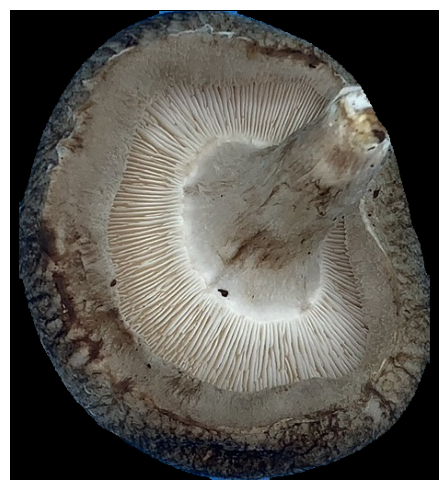

In [12]:
imgpath = "/home/data/0203_energee_after/cropBB/B/IMG_1703.JPEG"
img = cv2.imread(imgpath)
mask_and_img =cv2.bitwise_and(img, img, mask=mask)
plt.figure(figsize=(10, 5))
plt.imshow(mask_and_img[..., ::-1])  # BGR → RGB
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import size_module
analyzer = size_module.Size_taikakusen("/home/data/jikuari_maesyori/mask/collage_1/mask_1_2.jpg")
avg_diameter = analyzer.compute_diameters()
print(f"直径の平均: {avg_diameter:.2f} ピクセル")

# 可視化（オプション）
# analyzer.visualize()


In [ ]:
import os
from PIL import Image

def create_collages(input_folder, output_folder, cols=6, rows=4):
    """
    フォルダ内のすべての画像を使い、指定の列×行のグリッドで複数枚のコラージュを作成する。
    画像が足りない場合は、青い画像で空白を埋める。
    :param input_folder: 画像が保存されているフォルダ
    :param output_folder: 作成された画像を保存するフォルダ
    :param cols: 横の画像数
    :param rows: 縦の画像数
    """
    os.makedirs(output_folder, exist_ok=True)
    
    image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    total_images = len(image_files)

    # 必要な数のコラージュを作成するため、足りない画像は青い画像で埋める
    num_collages = total_images // (cols * rows) + (1 if total_images % (cols * rows) > 0 else 0)

    # 画像を足りない分だけ青い画像で埋める
    blue_image = Image.new('RGB', (100, 100), (0, 0, 255))  # 青い画像（100x100）

    # すべての画像を使いきるまでコラージュを作成
    index = 0
    for collage_num in range(num_collages):
        selected_images = []
        for _ in range(cols * rows):
            if index < total_images:
                selected_images.append(Image.open(os.path.join(input_folder, image_files[index])))
                index += 1
            else:
                selected_images.append(blue_image)  # 足りない分は青い画像で埋める
        
        # コラージュ画像のサイズを取得（最初の画像のサイズを基準にする）
        img_width, img_height = selected_images[0].size
        
        # コラージュの全体サイズ
        collage_width = cols * img_width
        collage_height = rows * img_height
        
        # 空のキャンバスを作成
        collage = Image.new('RGB', (collage_width, collage_height), (0, 0, 255))  # 背景は青
        
        # 画像をキャンバスに貼り付ける
        for i, img in enumerate(selected_images):
            x_offset = (i % cols) * img_width
            y_offset = (i // cols) * img_height
            collage.paste(img, (x_offset, y_offset))
        
        # コラージュ画像を保存
        output_path = os.path.join(output_folder, f'collage_{collage_num + 1}.jpg')
        collage.save(output_path)
        print(f'Saved: {output_path}')

# 使い方
input_folder = "/home/data/JA/SPE/"  # 画像があるフォルダのパス
output_folder = '/home/data/JA/SPE_folder'  # 結果を保存するフォルダのパス

create_collages(input_folder, output_folder)


In [ ]:
import os
import cv2
import numpy as np
from ultralytics import YOLO

# 入力と出力
input_folder = "/home/data/JA/SPE_folder"
base_output_path = "/home/data/JA/SPE"
crop_output_base = os.path.join(base_output_path, "crop")  # crop フォルダ
mask_output_base = os.path.join(base_output_path, "mask")  # mask フォルダ
combined_output_base = os.path.join(base_output_path, "combined")  # combined フォルダ

# モデルの読み込み
detection_model = YOLO('/home/YOLO/hukusuu_train/datasets/train7/weights/best.pt')
segmentation_model = YOLO("/home/YOLO/-327_seg/datasets/train2/weights/best.pt")

from string import ascii_uppercase
labels = list(ascii_uppercase)

# 通し番号（すべての画像で一意）
global_counter = 1

def process_image(image_path, collage_index):
    global global_counter

    results = detection_model.predict(image_path)
    orig_img = results[0].orig_img
    img_h, img_w, _ = orig_img.shape

    rows, cols = 4, 6
    cell_h, cell_w = img_h // rows, img_w // cols

    cell_bboxes = [[[] for _ in range(cols)] for _ in range(rows)]

    if results[0].boxes is not None:
        for box in results[0].boxes.xyxy:
            start_x, start_y, end_x, end_y = map(int, box)
            center_x = (start_x + end_x) // 2
            center_y = (start_y + end_y) // 2
            row_idx = min(center_y // cell_h, rows - 1)
            col_idx = min(center_x // cell_w, cols - 1)
            cell_bboxes[row_idx][col_idx].append((start_x, start_y, end_x, end_y))

    # フォルダの作成（フォルダの分け方をなくすため、まとめて1つのフォルダ）
    os.makedirs(crop_output_base, exist_ok=True)
    os.makedirs(mask_output_base, exist_ok=True)
    os.makedirs(combined_output_base, exist_ok=True)

    for r in range(rows):
        for c in range(cols):
            if not cell_bboxes[r][c]:
                continue

            for (sx, sy, ex, ey) in cell_bboxes[r][c]:
                clip_img = orig_img[sy:ey, sx:ex]

                # ファイル名生成
                filename = f"crop_{collage_index}_{global_counter}.jpg"  # crop のファイル名
                global_counter += 1

                # cropフォルダに保存
                cv2.imwrite(os.path.join(crop_output_base, filename), clip_img)

                # セグメンテーション
                mask_results = segmentation_model.predict(clip_img)
                if mask_results and mask_results[0].masks is not None:
                    mask = mask_results[0].masks.data[0].cpu().numpy()
                    mask = (mask * 255).astype(np.uint8)
                    mask_resized = cv2.resize(mask, (clip_img.shape[1], clip_img.shape[0]))

                    # maskフォルダに保存
                    mask_filename = f"mask_{collage_index}_{global_counter}.jpg"  # 変更: 'mask' プレフィックス
                    cv2.imwrite(os.path.join(mask_output_base, mask_filename), mask_resized)

                    mask_rgb = cv2.cvtColor(mask_resized, cv2.COLOR_GRAY2BGR)
                    combined_img = cv2.bitwise_and(clip_img, mask_rgb)

                    # combinedフォルダに保存
                    combined_filename = f"combined_{collage_index}_{global_counter}.jpg"  # combined のファイル名
                    cv2.imwrite(os.path.join(combined_output_base, combined_filename), combined_img)

# 全画像を処理
image_files = sorted(f for f in os.listdir(input_folder) if f.lower().endswith(('jpg', 'jpeg', 'png')))
for image_name in image_files:
    image_path = os.path.join(input_folder, image_name)

    # collage_1.jpg → 1 に変換
    collage_index = os.path.splitext(image_name)[0].split("_")[-1]
    if collage_index.isdigit():
        collage_index = int(collage_index)
    else:
        continue  # 整数でない場合スキップ

    print(f"Processing: {image_name}")
    process_image(image_path, collage_index)


In [ ]:
import cv2
import numpy as np
import os
import csv

# 処理したい画像が格納されているフォルダ
input_folder = "/home/data/JA/SPE/mask/"

# 結果を保存するCSVファイル
csv_file = "/home/data/JA/SPE/result_diameters.csv"

# CSVファイルにヘッダーがない場合はヘッダーを書き込む
header = ["filename", "min_diameter", "max_diameter", "mean_diameter"]
if not os.path.exists(csv_file):
    with open(csv_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(header)

# === フォルダ内の画像ファイルを取得 ===
image_files = [f for f in os.listdir(input_folder) if f.endswith('.jpg')]

# 各画像に対して処理を行う
for image_file in image_files:
    image_path = os.path.join(input_folder, image_file)
    
    # === マスク画像の読み込み（グレースケール） ===
    mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # 輪郭検出
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 最大輪郭のみ使用
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)

        # モーメントから重心計算
        M = cv2.moments(largest_contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            center_of_mass = np.array([cx, cy])
        else:
            print("面積ゼロの輪郭")
            center_of_mass = np.array([0, 0])
    else:
        print("輪郭が見つかりませんでした")
        center_of_mass = np.array([0, 0])

    # === 最小・最大距離初期化 ===
    min_distance = float('inf')
    max_distance = 0
    min_points = None
    max_points = None

    # 角度を変えながら探索（0〜179度）
    for angle in range(0, 180):
        angle_rad = np.deg2rad(angle)
        dx = np.cos(angle_rad)
        dy = np.sin(angle_rad)

        # 正方向に進む
        x, y = center_of_mass
        farthest_x, farthest_y = None, None
        while 0 <= int(x) < mask.shape[1] and 0 <= int(y) < mask.shape[0]:
            if mask_bin[int(y), int(x)] == 0:
                farthest_x, farthest_y = x, y
                break
            x += dx
            y += dy

        # 負方向に進む
        x, y = center_of_mass
        nearest_x, nearest_y = None, None
        while 0 <= int(x) < mask.shape[1] and 0 <= int(y) < mask.shape[0]:
            if mask_bin[int(y), int(x)] == 0:
                nearest_x, nearest_y = x, y
                break
            x -= dx
            y -= dy

        # 有効な点が見つかった場合のみ距離を計算
        if farthest_x is not None and nearest_x is not None:
            dist = np.sqrt(((farthest_x - nearest_x)-2)**2 + ((farthest_y - nearest_y)-2)**2)

            if dist < min_distance:
                min_distance = dist
                min_points = ((farthest_x, farthest_y), (nearest_x, nearest_y))

            if dist > max_distance:
                max_distance = dist
                max_points = ((farthest_x, farthest_y), (nearest_x, nearest_y))

    # 最小最大の平均を計算
    min_max_avg = (min_distance + max_distance) / 2 if min_distance != float('inf') else 0

    # 結果をCSVに書き込む
    with open(csv_file, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([image_file, min_distance, max_distance, min_max_avg])

    # === 結果を表示 ===
    print(f"画像: {image_file}")
    print(f"最小直径: {min_distance:.2f} ピクセル")
    print(f"最大直径: {max_distance:.2f} ピクセル")
    print(f"最小最大平均: {min_max_avg:.2f} ピクセル")



In [ ]:
import pandas as pd

# CSV読み込み
df = pd.read_csv(csv_file)  # ファイル名は適宜修正してください

# 換算係数（72px = 1cm）
px_per_cm = 72.0

# 新しい列を追加（cm単位）
df["min_cm"] = df["min_diameter"] / px_per_cm
df["max_cm"] = df["max_diameter"] / px_per_cm
df["mean_cm"] = df["mean_diameter"] / px_per_cm

df = df.applymap(lambda x: np.floor(x * 1000) / 1000 if isinstance(x, (int, float)) else x)

# 保存（上書きまたは別ファイル名で保存）
df.to_csv(csv_file, index=False)


In [ ]:
def assign_label(value):
    if 2.5 <= value < 4:
        return 'S'
    elif 4 <= value < 5:
        return 'M'
    elif 5 <= value < 6:
        return 'L'
    elif 6 <= value < 8:
        return '2L'
    elif value >= 8:
        return 'A'
    else:
        return 'その他'  # 2.5未満の値があれば（任意）

df['label'] = df['mean_cm'].apply(assign_label)
df.to_csv(csv_file, index=False)


In [ ]:
# #サイズ倍率変更
# import pandas as pd

# scale = 1.0

# # CSVファイルを読み込み
# df = pd.read_csv('/home/data/JA/SPE/result_diameters.csv')

# # 倍率をかける列（filenameとlabel以外）
# cols_to_scale = [col for col in df.columns if col not in ['filename', 'label']]

# # 各列に0.8をかける
# df[cols_to_scale] = df[cols_to_scale] * scale

# # 新しいCSVとして保存（元ファイルを上書きしたくない場合）
# df.to_csv(f'/home/data/JA/SPE/{scale}result_diameters.csv', index=False)


In [ ]:
#csvfile並び替え
#1=0.6.0,2=0.8,3=1
import pandas as pd

scale = 1.0
folder ="SPE"
# CSVの読み込み
df = pd.read_csv(f'/home/data/JA/{folder}/result_diameters.csv')

# mask_3: 変更なし
df_mask3 = df[df['filename'].str.startswith('mask_3')].copy()

# mask_2: 数値列を0.8倍（filenameとlabel以外）
df_mask2 = df[df['filename'].str.startswith('mask_2')].copy()
cols_mask2 = [col for col in df.columns if col not in ['filename', 'label']]
df_mask2[cols_mask2] *= 0.8

# mask_1: 数値列を0.6倍（filenameとlabel以外）
df_mask1 = df[df['filename'].str.startswith('mask_1')].copy()
cols_mask1 = [col for col in df.columns if col not in ['filename', 'label']]
df_mask1[cols_mask1] *= 0.6

# 結合と並べ替え
df_all = pd.concat([df_mask1, df_mask2, df_mask3])
df_all_sorted = df_all.sort_values(by='filename')

# 出力
df_all_sorted.to_csv(f'/home/data/JA_system/{scale}{folder}result_diameters.csv', index=False)




In [ ]:
def assign_label(value):
    if 2.5 <= value < 4:
        return 'S'
    elif 4 <= value < 5:
        return 'M'
    elif 5 <= value < 6:
        return 'L'
    elif 6 <= value < 8:
        return '2L'
    elif value >= 8:
        return 'A'
    else:
        return 'その他'  # 2.5未満の値があれば（任意）
# folder = "NOR"
scale_file = f"/home/data/JA_system/{scale}{folder}result_diameters.csv"
df_scale = pd.read_csv(scale_file)
df_scale['label'] = df_scale['mean_cm'].apply(assign_label)
df_scale.to_csv(scale_file, index=False)

In [ ]:
from PIL import Image
import os
import glob

# 入力と出力フォルダの指定
folder = "NOR"
folder2 = "mask"
input_dir = f'/home/data/JA/{folder}/{folder2}'
output_dir = f'/home/data/JA_system/{folder2}/{folder}'
os.makedirs(output_dir, exist_ok=True)

# すべての画像を処理
for filepath in glob.glob(os.path.join(input_dir, '*.jpg')):
    filename = os.path.basename(filepath)

    # 画像を読み込む
    img = Image.open(filepath)

    # リサイズ率の決定
    if filename.startswith(f'{folder2}_3'):
        resized_img = img  # 変更なし
    elif filename.startswith(f'{folder2}_2'):
        new_size = (int(img.width * 0.8), int(img.height * 0.8))
        resized_img = img.resize(new_size, Image.Resampling.LANCZOS)
    elif filename.startswith(f'{folder2}_1'):
        new_size = (int(img.width * 0.6), int(img.height * 0.6))
        resized_img = img.resize(new_size, Image.Resampling.LANCZOS)
    else:
        continue  # それ以外のファイルはスキップ

    # 保存
    save_path = os.path.join(output_dir, filename)
    resized_img.save(save_path)


In [14]:
import os 
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve
import re
import math
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score
import joblib
import time
from ultralytics import YOLO

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#特徴量抽出
import hida
import keijo
import size_module
#判別フェーズ
#特徴量抽出
folder = "SPE"
hida_tapple = hida.Hida_folder_jikuari(base_dir=f"/home/data/JA_system",subfolder=folder,method="45rotate")
result_hida = hida_tapple.run_all()
size_tapple = size_module.Size_folder(base_dir=f"/home/data/JA_system",subfolder=folder)
result_size = size_tapple.run()
keijo_tapple = keijo.Keijo_folder(base_dir=f"/home/data/JA_system",subfolder=folder)
result_keijo = keijo_tapple.run()

/usr/local/lib/python3.11/site-packages/hida/__main__.py:494: RuntimeWarning: invalid value encountered in scalar divide
  return Tr / Tm
/usr/local/lib/python3.11/site-packages/hida/__main__.py:494: RuntimeWarning: divide by zero encountered in scalar divide
  return Tr / Tm


探索対象フォルダ: /home/data/JA_system/mask/SPE
📂 フォルダ: /home/data/JA_system/mask/SPE に画像 74 枚


In [5]:
import pandas as pd
dict_hida =dict(result_hida)
dict_size = dict(result_size)
dict_keijo = dict(result_keijo)
# 結果を結合
merged = []
for filename in dict_hida.keys() & dict_size.keys() & dict_keijo.keys():
    merged.append({
        'filename': filename,
        'MSE': dict_keijo[filename],
        'size_count': dict_size[filename],
        'R': dict_hida[filename]
    })

In [6]:
df = pd.DataFrame(merged)
df.to_csv(f'/home/data/JA_system/{folder}feature.csv', index=False)

In [ ]:
import pandas as pd
scale = 1.0
# folder = "NOR"
# 元データ：MSE, R などが入った CSV
df1 = pd.read_csv(f'/home/data/JA_system/{folder}feature.csv')

# ラベルが入った CSV
df2 = pd.read_csv(f"/home/data/JA_system/{scale}{folder}result_diameters.csv")

# 'label' 列だけを df2 から抜き出して、filename で結合
df_merged = df1.merge(df2[['filename', 'label']], on='filename', how='left')

# 結果を保存（オプション）
df_merged.to_csv(f'/home/data/JA_system/merged{folder}feature.csv', index=False)


In [9]:
#NORの方のlabel値付ける
# "2L = 0, L = 1, M = 2, S = 3, A = 4 ,
import pandas as pd

# CSV読み込み
df = pd.read_csv('/home/data/JA_system/mergedNORfeature.csv')  # ← ファイル名を適宜変更

# ラベルのマッピング定義
label_map = {'2L': 0, 'L': 1, 'M': 2, 'S': 3, 'A': 4}

# 数値ラベル列を追加または上書き
df['label'] = df['label'].map(label_map)

# 保存（必要に応じて）
df.to_csv('/home/data/JA_system/2mergedNORfeature.csv', index=False)


In [10]:
#SPEの方のlabel値付ける
# "2L = 5, L = 6, M = 7, S = 8, A = 9 ,
import pandas as pd

# CSV読み込み
df = pd.read_csv('/home/data/JA_system/mergedSPEfeature.csv')  # ← ファイル名を適宜変更

# ラベルのマッピング定義
label_map = {'2L': 5, 'L': 6, 'M': 7, 'S': 8, 'A': 9}

# 数値ラベル列を追加または上書き
df['label'] = df['label'].map(label_map)

# 保存（必要に応じて）
df.to_csv('/home/data/JA_system/2mergedSPEfeature.csv', index=False)


In [11]:
#SPEの方のfilenameの最初にSをつける
import pandas as pd

# CSV読み込み
df = pd.read_csv('/home/data/JA_system/2mergedSPEfeature.csv')  # ← ファイル名を適宜変更

# 先頭に "S" を追加
df['filename'] = 'S' + df['filename']

# 保存（必要に応じて）
df.to_csv('/home/data/JA_system/2mergedSPEfeature.csv', index=False)


In [1]:
import pandas as pd

# CSVファイルを読み込む（例: 'data.csv'）
df = pd.read_csv('/home/data/JA_system/mergedALLfeature.csv')

# label ごとの件数を表示
label_counts = df['label'].value_counts().sort_index()
print(label_counts)


label
0    21
1    19
2    17
3     8
4     4
5    13
6    27
7    20
8    11
9     3
Name: count, dtype: int64


In [12]:
import pandas as pd

# CSV読み込み
df1 = pd.read_csv('/home/data/JA_system/2mergedNORfeature.csv')
df2 = pd.read_csv('/home/data/JA_system/2mergedSPEfeature.csv')

# 縦方向に結合
df_concat = pd.concat([df1, df2], ignore_index=True)

# 保存（任意）
df_concat.to_csv('/home/data/JA_system/mergedALLfeature.csv', index=False)



Train Data Class Distribution:
label
0    15
1    13
2    12
3     5
4     3
5     9
6    19
7    14
8     8
9     2
Name: count, dtype: int64

Test Data Class Distribution:
label
0    6
1    6
2    5
3    3
4    1
5    4
6    8
7    6
8    3
9    1
Name: count, dtype: int64
              precision  recall  f1-score  support
0                0.6250  0.8333    0.7143   6.0000
1                0.7500  0.5000    0.6000   6.0000
2                1.0000  0.6000    0.7500   5.0000
3                0.0000  0.0000    0.0000   3.0000
4                0.0000  0.0000    0.0000   1.0000
5                1.0000  0.2500    0.4000   4.0000
6                0.6154  1.0000    0.7619   8.0000
7                0.7500  1.0000    0.8571   6.0000
8                0.5000  1.0000    0.6667   3.0000
9                0.0000  0.0000    0.0000   1.0000
accuracy         0.6744  0.6744    0.6744   0.6744
macro avg        0.5240  0.5183    0.4750  43.0000
weighted avg     0.6552  0.6744    0.6157  43.0000


/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


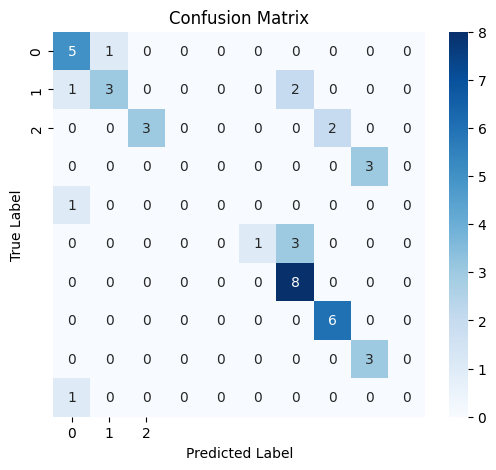

In [30]:
#SVM

# === 1. データの読み込み ===
merged_data_csv = f"/home/data/JA_system/Tai_mergedALLfeature.csv"
df = pd.read_csv(merged_data_csv)
# === 2. 特徴量とターゲット変数の定義 ===
X = df[["MSE", "size_count", "R"]]  # 特徴量
y = df["label"]  # 目的変数

# === 3. 訓練データとテストデータに分割 ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# 訓練データとテストデータのクラスごとのカウント
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# 結果を表示
print("Train Data Class Distribution:")
print(train_counts)
print("\nTest Data Class Distribution:")
print(test_counts)


# === 4. 特徴量の標準化 ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === 5. SVMの学習 (RBFカーネル) ===
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr')
svm_model.fit(X_train, y_train)


# 学習済みモデルを保存
model_path = "svm_model_JA_tai.pkl"
joblib.dump(svm_model, model_path)

# 標準化のスケーラーも保存
scaler_path = "scaler_JA_tai.pkl"
joblib.dump(scaler, scaler_path)


# === 6. 予測と評価 ===
y_pred = svm_model.predict(X_test)

# 精度の表示
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred, average='macro')
# recall = recall_score(y_test, y_pred, average='macro')
# f1 = f1_score(y_test, y_pred, average='macro')
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1: {f1:.4f}")

# クラス分類の詳細なレポート
# print("Classification Report:\n", classification_report(y_test, y_pred))
# レポートを辞書形式で取得
report_dict = classification_report(y_test, y_pred, output_dict=True)

# DataFrameに変換
report_df = pd.DataFrame(report_dict).transpose()

# 表示（必要に応じて四捨五入）
print(report_df.round(4))
# === 7. 混同行列の可視化 ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [22]:
# === モデルとスケーラーの読み込み ===
model_path = "/home/src/size/svm_model_JA_tai.pkl"
scaler_path = "/home/src/size/scaler_JA_tai.pkl"

svm_model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

# === 新しいデータの読み込み ===
# df = pd.DataFrame(merged)
df = pd.read_csv(f'/home/data/JA_system/Tai_mergedALLfeature.csv')
df = pd.DataFrame(df)

# === 特徴量の抽出と標準化 ===
X_new = df[["MSE", "size_count", "R"]]  # 学習時と同じ特徴量を使用
X_new = scaler.transform(X_new)  # 標準化

# === 予測 ===
y_pred_new = svm_model.predict(X_new)

# 結果をDataFrameに追加
df["Predicted_Label"] = y_pred_new

# 予測結果の確認
print([["MSE", "size_count", "R", "Predicted_Label"]])

# CSVとして保存（オプション）
df.to_csv(f"/home/data/JA_system/Tai_predicted_results.csv", index=False)


[['MSE', 'size_count', 'R', 'Predicted_Label']]


In [23]:
# 正解ラベルと予測ラベル
y_true = df["label"]
y_pred = df["Predicted_Label"]

# 精度 (accuracy)
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# 詳細レポート
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


Accuracy: 0.6923076923076923

Classification Report:
              precision    recall  f1-score   support

           0     0.7391    0.8095    0.7727        21
           1     0.8182    0.4737    0.6000        19
           2     0.8182    0.5294    0.6429        17
           3     0.0000    0.0000    0.0000         8
           4     1.0000    0.2500    0.4000         4
           5     0.6667    0.6154    0.6400        13
           6     0.6216    0.8519    0.7188        27
           7     0.6667    1.0000    0.8000        20
           8     0.6471    1.0000    0.7857        11
           9     1.0000    0.3333    0.5000         3

    accuracy                         0.6923       143
   macro avg     0.6978    0.5863    0.5860       143
weighted avg     0.6845    0.6923    0.6575       143



/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


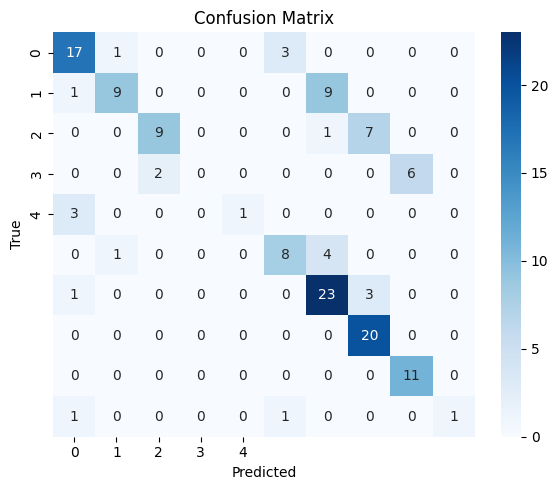

In [26]:
cm = confusion_matrix(y_true, y_pred)

# 混同行列のプロット
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


Accuracy: 0.7972027972027972

Classification Report:
              precision    recall  f1-score   support

           0     0.9348    0.6232    0.7478        69
           1     0.7320    0.9595    0.8304        74

    accuracy                         0.7972       143
   macro avg     0.8334    0.7913    0.7891       143
weighted avg     0.8298    0.7972    0.7906       143



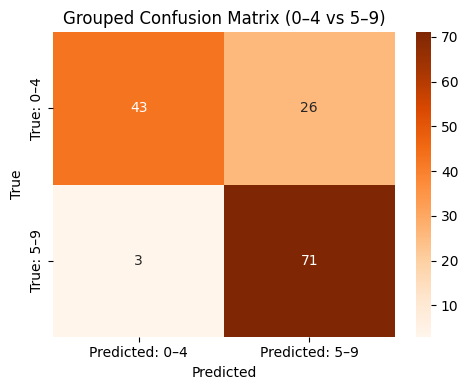

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# クラス0〜4 → 0（小さいクラス）, クラス5〜9 → 1（大きいクラス）に変換
y_true_grouped = np.where(df["label"] <= 4, 0, 1)
y_pred_grouped = np.where(df["Predicted_Label"] <= 4, 0, 1)

# 精度 (accuracy)
accuracy = accuracy_score(y_true_grouped, y_pred_grouped)
print("Accuracy:", accuracy)

# 詳細レポート
print("\nClassification Report:")
print(classification_report(y_true_grouped, y_pred_grouped, digits=4))

# 混同行列の作成
cm_grouped = confusion_matrix(y_true_grouped, y_pred_grouped)

# プロット
plt.figure(figsize=(5, 4))
sns.heatmap(cm_grouped, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Predicted: 0–4", "Predicted: 5–9"],
            yticklabels=["True: 0–4", "True: 5–9"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Grouped Confusion Matrix (0–4 vs 5–9)")
plt.tight_layout()
plt.show()


Accuracy: 0.7552447552447552

Classification Report:
              precision    recall  f1-score   support

           0     0.7778    0.8235    0.8000        34
           1     0.8627    0.9565    0.9072        46
           2     0.6429    0.9730    0.7742        37
           3     0.0000    0.0000    0.0000        19
           4     0.0000    0.0000    0.0000         7

    accuracy                         0.7552       143
   macro avg     0.4567    0.5506    0.4963       143
weighted avg     0.6288    0.7552    0.6824       143



/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


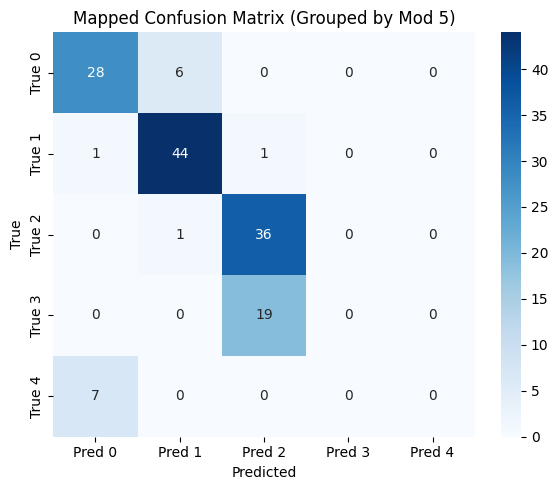

In [20]:
from sklearn.metrics import accuracy_score, classification_report

# 0と5, 1と6, ..., 4と9 を同じラベルにする（5クラス化）
y_true_mapped = df["label"] % 5
y_pred_mapped = df["Predicted_Label"] % 5

# 精度の表示
accuracy = accuracy_score(y_true_mapped, y_pred_mapped)
print("Accuracy:", accuracy)

# 詳細レポート
print("\nClassification Report:")
print(classification_report(y_true_mapped, y_pred_mapped, digits=4))

# 混同行列の作成とプロット
cm_mapped = confusion_matrix(y_true_mapped, y_pred_mapped)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_mapped, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(5)],
            yticklabels=[f"True {i}" for i in range(5)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Mapped Confusion Matrix (Grouped by Mod 5)")
plt.tight_layout()
plt.show()
